In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.cluster.hierarchy as sch
from numpy.linalg import norm
from scipy.spatial.distance import pdist

In [3]:
OHCO = ['book_title', 'chap_num', 'para_num', 'sent_num', 'token_num']

In [4]:
TFIDF_BAG = pd.read_csv("TFIDF.csv").set_index(["book_title"])
LIB = pd.read_csv("Corpus_Lib.csv")
LIB["Label"] = LIB["book_title"]
LIB.set_index("book_title", inplace=True)


In [5]:
PAIRS = pd.DataFrame(index=pd.MultiIndex.from_product([LIB.index.tolist(), LIB.index.tolist()])).reset_index()
PAIRS = PAIRS[PAIRS.level_0 < PAIRS.level_1].set_index(['level_0','level_1'])
PAIRS

Empty DataFrame
Columns: []
Index: [(The Mystery of Edwin Drood, The Old Curiosity Shop), (Dombey and Son, The Old Curiosity Shop), (Dombey and Son, The Mystery of Edwin Drood), (Dombey and Son, Nicholas Nickleby), (Dombey and Son, Martin Chuzzlewit), (Dombey and Son, Hard Times 1), (Dombey and Son, Hard Times 2), (Dombey and Son, Hard Times 3), (Dombey and Son, Oliver Twist), (Dombey and Son, Pickwick Papers), (Dombey and Son, Great Expectations), (Dombey and Son, Little Dorrit 1), (Dombey and Son, Little Dorrit 2), (Dombey and Son, Our Mutual Friend 1), (Dombey and Son, Our Mutual Friend 2), (Dombey and Son, Our Mutual Friend 3), (Dombey and Son, Our Mutual Friend 4), (Nicholas Nickleby, The Old Curiosity Shop), (Nicholas Nickleby, The Mystery of Edwin Drood), (Nicholas Nickleby, Oliver Twist), (Nicholas Nickleby, Pickwick Papers), (Nicholas Nickleby, Our Mutual Friend 1), (Nicholas Nickleby, Our Mutual Friend 2), (Nicholas Nickleby, Our Mutual Friend 3), (Nicholas Nickleby, Our Mutual Friend 4), (Bleak House, The Old Curiosity Shop), (Bleak House, The Mystery of Edwin Drood), (Bleak House, Dombey and Son), (Bleak House, Nicholas Nickleby), (Bleak House, Martin Chuzzlewit), (Bleak House, David Copperfield), (Bleak House, Hard Times 1), (Bleak House, Hard Times 2), (Bleak House, Hard Times 3), (Bleak House, Oliver Twist), (Bleak House, Pickwick Papers), (Bleak House, Great Expectations), (Bleak House, Little Dorrit 1), (Bleak House, Little Dorrit 2), (Bleak House, Our Mutual Friend 1), (Bleak House, Our Mutual Friend 2), (Bleak House, Our Mutual Friend 3), (Bleak House, Our Mutual Friend 4), (Martin Chuzzlewit, The Old Curiosity Shop), (Martin Chuzzlewit, The Mystery of Edwin Drood), (Martin Chuzzlewit, Nicholas Nickleby), (Martin Chuzzlewit, Oliver Twist), (Martin Chuzzlewit, Pickwick Papers), (Martin Chuzzlewit, Our Mutual Friend 1), (Martin Chuzzlewit, Our Mutual Friend 2), (Martin Chuzzlewit, Our Mutual Friend 3), (Martin Chuzzlewit, Our Mutual Friend 4), (David Copperfield, The Old Curiosity Shop), (David Copperfield, The Mystery of Edwin Drood), (David Copperfield, Dombey and Son), (David Copperfield, Nicholas Nickleby), (David Copperfield, Martin Chuzzlewit), (David Copperfield, Hard Times 1), (David Copperfield, Hard Times 2), (David Copperfield, Hard Times 3), (David Copperfield, Oliver Twist), (David Copperfield, Pickwick Papers), (David Copperfield, Great Expectations), (David Copperfield, Little Dorrit 1), (David Copperfield, Little Dorrit 2), (David Copperfield, Our Mutual Friend 1), (David Copperfield, Our Mutual Friend 2), (David Copperfield, Our Mutual Friend 3), (David Copperfield, Our Mutual Friend 4), (A Tale of Two Cities 1, The Old Curiosity Shop), (A Tale of Two Cities 1, The Mystery of Edwin Drood), (A Tale of Two Cities 1, Dombey and Son), (A Tale of Two Cities 1, Nicholas Nickleby), (A Tale of Two Cities 1, Bleak House), (A Tale of Two Cities 1, Martin Chuzzlewit), (A Tale of Two Cities 1, David Copperfield), (A Tale of Two Cities 1, A Tale of Two Cities 2), (A Tale of Two Cities 1, A Tale of Two Cities 3), (A Tale of Two Cities 1, Hard Times 1), (A Tale of Two Cities 1, Hard Times 2), (A Tale of Two Cities 1, Hard Times 3), (A Tale of Two Cities 1, Oliver Twist), (A Tale of Two Cities 1, Pickwick Papers), (A Tale of Two Cities 1, Great Expectations), (A Tale of Two Cities 1, Little Dorrit 1), (A Tale of Two Cities 1, Little Dorrit 2), (A Tale of Two Cities 1, Our Mutual Friend 1), (A Tale of Two Cities 1, Our Mutual Friend 2), (A Tale of Two Cities 1, Our Mutual Friend 3), (A Tale of Two Cities 1, Our Mutual Friend 4), (A Tale of Two Cities 1, Barnaby Rudge), (A Tale of Two Cities 2, The Old Curiosity Shop), (A Tale of Two Cities 2, The Mystery of Edwin Drood), (A Tale of Two Cities 2, Dombey and Son), (A Tale of Two Cities 2, Nicholas Nickleby), (A Tale of Two Cities 2, Bleak House), (A Tale of Two Cities 2, Martin Chuzzlewit), (A Tale of Two Cities 2, David Copperfield), (A Tale of Two Cities 2, A 

In [6]:
PAIRS.index.names = ['doc_a', 'doc_b']
PAIRS.shape

(253, 0)

In [7]:
TFIDF = TFIDF_BAG.groupby(OHCO[:1]).mean()

In [8]:
TFIDF

,0,000,1,12,12d,13,14th,1500,1747,1757,...,zest,zests,zig,zigzag,zigzagged,zone,zoo,zoodle,zooks,zounds
book_title,,,,,,,,,,,,,,,,,,,,,
A Tale of Two Cities 1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
A Tale of Two Cities 2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
A Tale of Two Cities 3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000093,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Barnaby Rudge,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000005,0.00000,0.000010,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000018
Bleak House,0.000000,0.000000,0.000006,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000004,0.00000,0.000007,0.000000,0.000000,0.000020,0.000000,0.000013,0.000000,0.000000
David Copperfield,0.000000,0.000000,0.000000,0.000000,0.000013,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.00000,0.000000,0.000008,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Dombey and Son,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.00001,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Great Expectations,0.000000,0.000000,0.000012,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000007,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Hard Times 1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [9]:
V = TFIDF_BAG.astype(bool).sum().to_frame('df') #TFIDF_BAG.mean().to_frame('mean_tfidf')
V.index.name = 'term_str'
N = len(TFIDF_BAG)
V['dp'] = V.df / N
V['di'] = np.log2(1/V.dp)
V['dh'] = V.dp * V.di

In [10]:
sig_thresh = .2

In [11]:
SIGS = V[V.dh >= sig_thresh]
(len(SIGS) / len(V)) * 100, len(SIGS)

(52.52376796950351, 22872)

In [12]:
TFIDF_SIGS = TFIDF[SIGS.index].copy()
TFIDF_SIGS

term_str,1,2,4,5,6,aa,aaron,aback,abandon,abandoning,...,zeal,zealous,zealously,zenith,zephyrs,zest,zests,zig,zigzag,zone
book_title,,,,,,,,,,,,,,,,,,,,,
A Tale of Two Cities 1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,0.000000
A Tale of Two Cities 2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000021,0.000013,0.000027,...,0.000000,0.000010,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,0.000000
A Tale of Two Cities 3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000015,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,0.000000
Barnaby Rudge,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000007,0.000000,...,0.000018,0.000008,0.000014,0.000007,0.00000,0.000005,0.00000,0.000010,0.000000,0.000000
Bleak House,0.000006,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000004,0.000016,0.000005,...,0.000000,0.000012,0.000000,0.000005,0.00000,0.000004,0.00000,0.000007,0.000000,0.000020
David Copperfield,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000004,0.000016,0.000000,...,0.000003,0.000002,0.000010,0.000000,0.00000,0.000000,0.00000,0.000000,0.000008,0.000000
Dombey and Son,0.000000,0.000000,0.000000,0.000000,0.000000,0.000014,0.000000,0.000034,0.000008,0.000011,...,0.000011,0.000010,0.000000,0.000005,0.00001,0.000000,0.00001,0.000000,0.000000,0.000000
Great Expectations,0.000012,0.000047,0.000019,0.000000,0.000000,0.000000,0.000000,0.000008,0.000000,0.000000,...,0.000010,0.000008,0.000000,0.000000,0.00000,0.000007,0.00000,0.000000,0.000000,0.000000
Hard Times 1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,0.000000


In [13]:
pdist(TFIDF_SIGS, 'cosine')

array([0.32414084, 0.43659937, 0.98054497, 0.99459903, 0.99256116,
       0.99518359, 0.9867412 , 0.9980742 , 0.99778315, 0.99813981,
       0.9939968 , 0.99320153, 0.9954538 , 0.98966102, 0.99735947,
       0.99687548, 0.99820327, 0.99822466, 0.99815375, 0.99812858,
       0.99602813, 0.98942706, 0.20599327, 0.98765372, 0.99446064,
       0.99293747, 0.99597048, 0.99569877, 0.99846678, 0.99874145,
       0.99890069, 0.99449586, 0.99097238, 0.9958686 , 0.98164528,
       0.99789879, 0.99751603, 0.99758123, 0.99821518, 0.99781827,
       0.99793867, 0.99629072, 0.98735857, 0.98447611, 0.9948486 ,
       0.9944725 , 0.99561061, 0.99640961, 0.99840252, 0.99814726,
       0.99870626, 0.99560731, 0.99482308, 0.99512944, 0.97867257,
       0.998024  , 0.99772417, 0.99809253, 0.99858242, 0.99834931,
       0.99674558, 0.99707715, 0.99326334, 0.97116194, 0.96963541,
       0.9739665 , 0.90381813, 0.9937493 , 0.99545629, 0.99492923,
       0.99247678, 0.99057943, 0.9828151 , 0.97220488, 0.98815

In [14]:
L0 = TFIDF_SIGS.astype('bool').astype('int')    # Binary (Pseudo L)
L1 = TFIDF_SIGS.apply(lambda x: x / x.sum(), 1) # Probabilistic
L2 = TFIDF_SIGS.apply(lambda x: x / norm(x), 1)

In [15]:
PAIRS['cityblock'] = pdist(TFIDF_SIGS, 'cityblock')
PAIRS['cityblock1'] = pdist(L1, 'cityblock')
PAIRS['cityblock2'] = pdist(L2, 'cityblock')
PAIRS['euclidean'] = pdist(TFIDF_SIGS, 'euclidean')
PAIRS['euclidean2'] = pdist(L2, 'euclidean') # Should be the same as cosine (colinear)
PAIRS['cosine'] = pdist(TFIDF_SIGS, 'cosine')
PAIRS['cosine2'] = pdist(L2, 'cosine')
PAIRS['jaccard'] = pdist(L0, 'jaccard')
PAIRS['dice'] = pdist(L0, 'dice')
PAIRS['js'] = pdist(L1, 'jensenshannon') 

In [16]:
def hac(sim_method='cosine', linkage_method='complete', color_thresh=.3, figsize=(10, 10)):

    sims = PAIRS[sim_method]
    
    tree = sch.linkage(sims, method=linkage_method)
    
    labels = LIB.Label
    
    sch.dendrogram(tree, 
        labels=labels, 
        orientation="left", 
        count_sort=True,
        distance_sort=True,
        above_threshold_color='.75',
        color_threshold=color_thresh
    )
    ax = plt.gca()
    ax.axvline(color_thresh, c='gray', ls='--')

    plt.tick_params(axis='both', which='major', labelsize=10)    

    sns.despine(left=True, bottom=True)

    plt.title(f"{sim_method} + {linkage_method} ({color_thresh})", y=1.05)
    

## RIFF 3

/opt/anaconda3/lib/python3.13/site-packages/scipy/cluster/hierarchy.py:3414: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ivl.append(labels[int(i - n)])


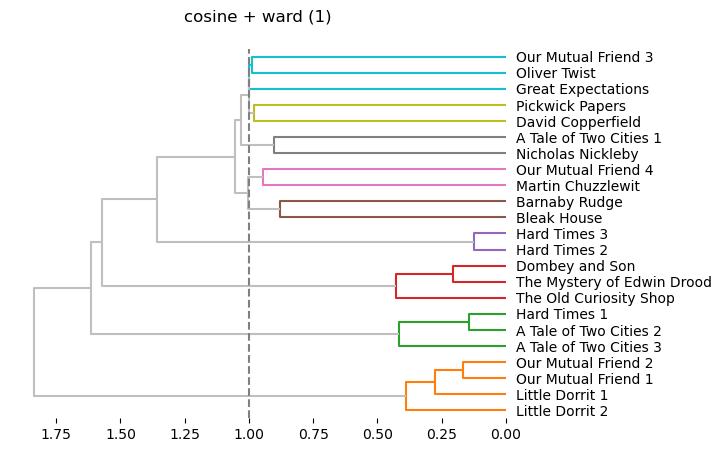

In [26]:
hac('cosine', 'ward', color_thresh=1)

/opt/anaconda3/lib/python3.13/site-packages/scipy/cluster/hierarchy.py:3414: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ivl.append(labels[int(i - n)])


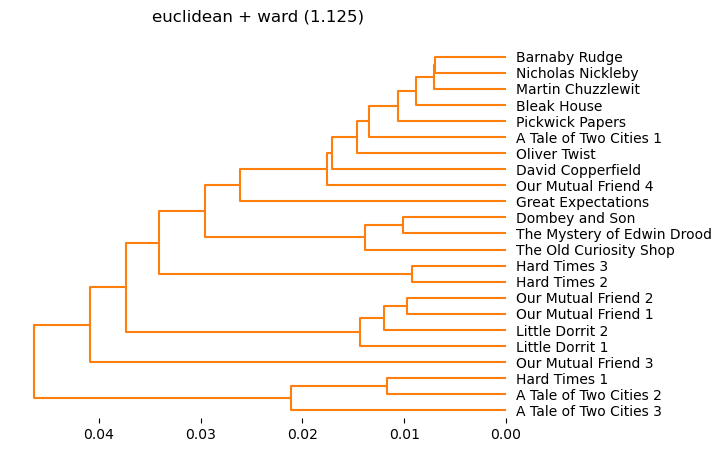

In [18]:
hac('euclidean', 'ward', color_thresh=1.125)

/opt/anaconda3/lib/python3.13/site-packages/scipy/cluster/hierarchy.py:3414: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ivl.append(labels[int(i - n)])


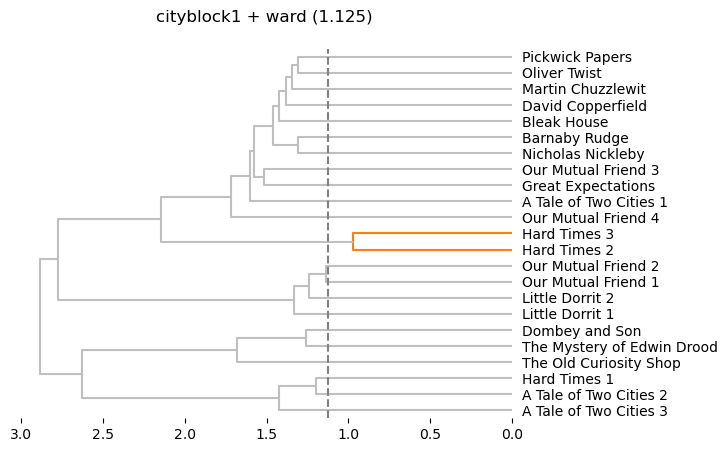

In [19]:
hac('cityblock1', 'ward', color_thresh=1.125)

/opt/anaconda3/lib/python3.13/site-packages/scipy/cluster/hierarchy.py:3414: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ivl.append(labels[int(i - n)])


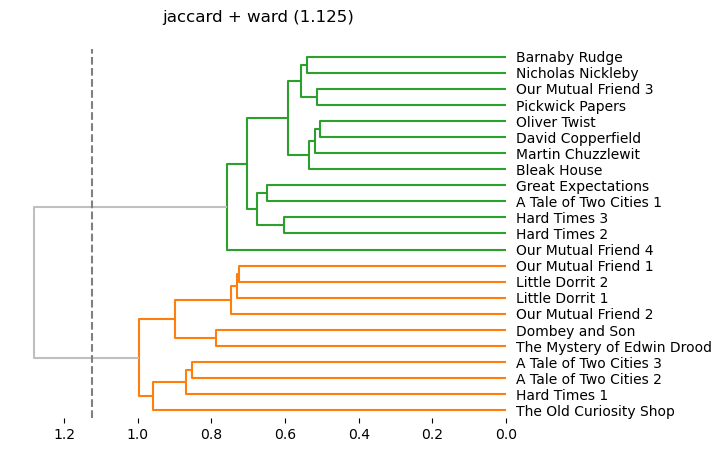

In [20]:
hac('jaccard', 'ward', color_thresh=1.125)

/opt/anaconda3/lib/python3.13/site-packages/scipy/cluster/hierarchy.py:3414: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ivl.append(labels[int(i - n)])


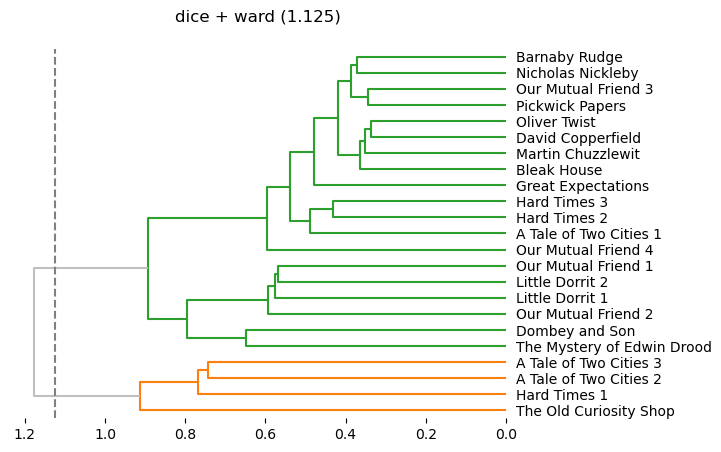

In [21]:
hac('dice', 'ward', color_thresh=1.125)

/opt/anaconda3/lib/python3.13/site-packages/scipy/cluster/hierarchy.py:3414: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ivl.append(labels[int(i - n)])


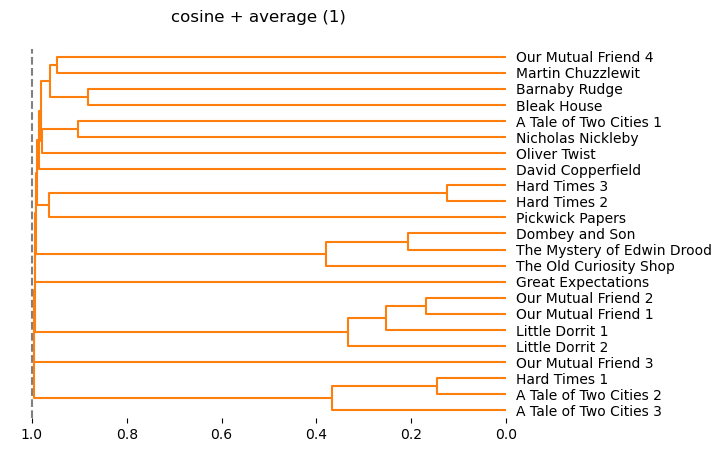

In [30]:
hac('cosine', 'average', color_thresh=1)